In [34]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

RANDOM_STATE = 42


sns.set(style="whitegrid")


In [35]:
url = "Data/CC GENERAL.csv"
df = pd.read_csv(url)
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [36]:
df.drop(columns=['CUST_ID'], inplace=True)

In [37]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

log_transform = FunctionTransformer(np.log1p, validate=False)

log_columns = [
    'BALANCE',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'CASH_ADVANCE_TRX',
    'PURCHASES_TRX'
]

normal_columns =[
    'BALANCE_FREQUENCY',
    'PURCHASES_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY',
    'PURCHASES_INSTALLMENTS_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY',
    'PRC_FULL_PAYMENT',
    'TENURE'
]

In [38]:
log_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transform),
    ("scaler", StandardScaler())
])

normal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [39]:
processor = ColumnTransformer([
    ("log_features", log_pipeline, log_columns),

    ("normal_features", normal_pipeline, normal_columns )
])

In [40]:
processor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_features', ...), ('normal_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name``

In [41]:
from sklearn.decomposition import PCA

In [42]:
preprocess_pipeline = Pipeline([
    ("preprocessor", processor)
])

X_processed = preprocess_pipeline.fit_transform(df)

In [43]:
from sklearn.decomposition import PCA

pca = PCA()

X_temp = pca.fit_transform(X_processed) #X_temp is just for visualization

In [44]:
import numpy as np

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print(cumulative_variance)

[0.33877054 0.55840919 0.65219208 0.72608353 0.79173766 0.84171379
 0.88340692 0.91484849 0.94051003 0.9588504  0.97155219 0.98027876
 0.98719034 0.99286002 0.99565511 0.99827391 1.        ]


In [45]:
cumulative_variance

array([0.33877054, 0.55840919, 0.65219208, 0.72608353, 0.79173766,
       0.84171379, 0.88340692, 0.91484849, 0.94051003, 0.9588504 ,
       0.97155219, 0.98027876, 0.98719034, 0.99286002, 0.99565511,
       0.99827391, 1.        ])

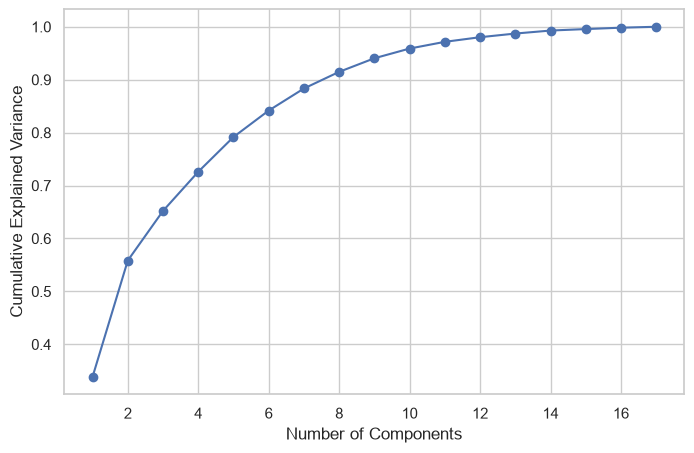

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1,len(cumulative_variance)+1),
         cumulative_variance,
         marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

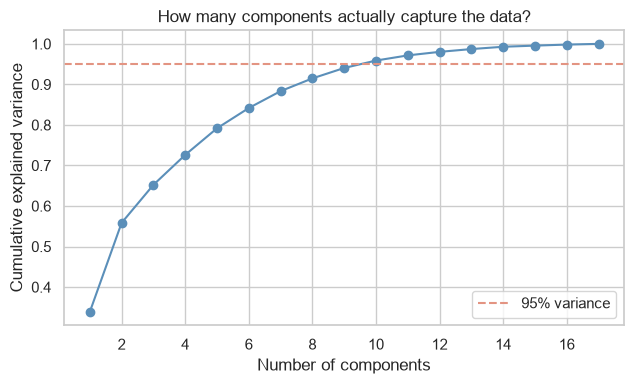

Components needed for 95% variance: 10 (out of 17)


In [47]:


# cum_var = np.cumsum(X_pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, "o-", color="#5B8FB9")
ax.axhline(0.95, color="#E39482", linestyle="--", label="95% variance")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("How many components actually capture the data?")
ax.legend()
plt.tight_layout()
plt.show()

n_comp_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)
print(f"Components needed for 95% variance: {n_comp_95} (out of {X_temp.shape[1]})")


In [48]:
pca = PCA(n_components=10,
          random_state=42)

X_pca = pca.fit_transform(X_processed)

In [49]:
wcss = []

from sklearn.cluster import KMeans

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

In [50]:
print(len(wcss))

9


In [51]:
wcss

[107092.77567363551,
 89467.42348172535,
 80371.66104734928,
 71916.06057285164,
 65665.00343088694,
 62467.729054506315,
 60125.6179112189,
 56794.534883656495,
 53629.17587487555]

## Plot the elbow curve

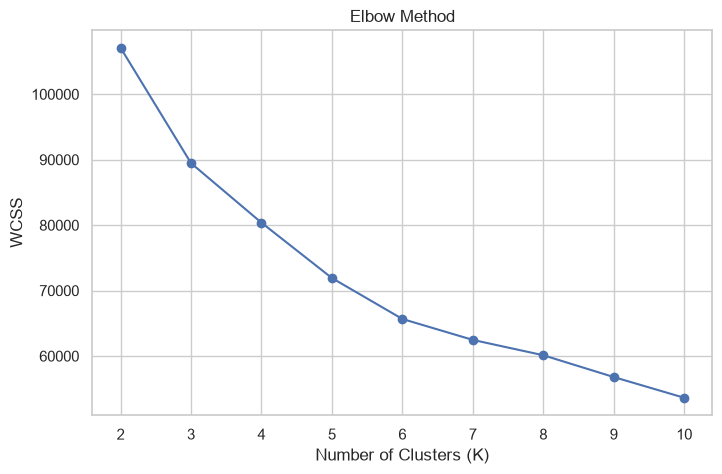

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

Silhouette Score

The elbow method alone is not enough.

Now calculate the silhouette score.

In [53]:
from sklearn.metrics import silhouette_score

scores=[]

for k in range(2,11):

    model=KMeans(
        n_clusters=k,
        random_state=42
    )

    labels=model.fit_predict(X_pca)

    score=silhouette_score(
        X_pca,
        labels
    )

    scores.append(score)

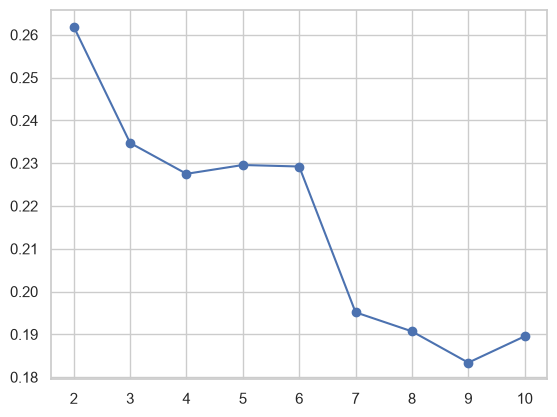

In [54]:
plt.plot(range(2,11),
         scores,
         marker="o")
plt.show()

In [55]:
for k, score in zip(range(2,11), scores):
    print(f"K={k}  Silhouette Score={score:.4f}")

K=2  Silhouette Score=0.2619
K=3  Silhouette Score=0.2347
K=4  Silhouette Score=0.2275
K=5  Silhouette Score=0.2296
K=6  Silhouette Score=0.2292
K=7  Silhouette Score=0.1951
K=8  Silhouette Score=0.1907
K=9  Silhouette Score=0.1834
K=10  Silhouette Score=0.1895


In [56]:
from sklearn.cluster import KMeans

kmeans_2 = KMeans(n_clusters=2, random_state=42)

clusters_2 = kmeans_2.fit_predict(X_pca)

In [57]:
kmeans_3 = KMeans(n_clusters=3, random_state=42)

clusters_3 = kmeans_3.fit_predict(X_pca)

In [58]:
kmeans_6 = KMeans(n_clusters=6, random_state=42)

clusters_6 = kmeans_6.fit_predict(X_pca)

## Creating copies of original Data Frame

In [59]:
df_k2 = df.copy()
df_k3 = df.copy()
df_k6 = df.copy()

## Adding Cluster Labels

In [60]:
df_k2["Cluster"] = clusters_2

df_k3["Cluster"] = clusters_3

df_k6["Cluster"] = clusters_6

## Seeing how many customers are in each cluster

In [61]:
df_k2["Cluster"].value_counts()

Cluster
1    5787
0    3163
Name: count, dtype: int64

In [62]:
df_k3["Cluster"].value_counts()

Cluster
0    3178
1    2909
2    2863
Name: count, dtype: int64

In [63]:
df_k6["Cluster"].value_counts()

Cluster
2    2196
3    1696
4    1463
1    1372
0    1218
5    1005
Name: count, dtype: int64

## Compare average feature values


In [64]:
df_k2.dtypes

BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
Cluster                               int32
dtype: object

In [65]:
df_k2.groupby("Cluster").mean().round(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2363.34,0.90,151.58,120.70,30.92,2162.68,0.10,0.06,0.04,0.29,7.15,1.73,4309.07,1785.66,1106.34,0.04,11.32
1,1127.84,0.86,1468.68,850.27,618.84,331.84,0.71,0.28,0.54,0.05,1.12,21.80,4595.74,1704.44,731.42,0.22,11.62


In [66]:
df_k3.groupby("Cluster").mean().round(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2060.69,0.98,2306.27,1432.05,874.58,774.13,0.84,0.46,0.61,0.10,2.57,32.80,5772.31,2644.88,1205.76,0.16,11.79
1,232.31,0.72,467.82,176.97,291.33,38.24,0.52,0.08,0.43,0.01,0.14,8.30,3300.20,705.23,217.61,0.27,11.38
2,2367.23,0.92,100.76,82.59,18.22,2161.88,0.07,0.04,0.03,0.30,7.17,1.15,4289.00,1765.53,1097.21,0.03,11.35


In [67]:
df_k6.groupby("Cluster").mean().round(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,3504.84,0.97,1359.32,759.87,599.72,2936.90,0.69,0.29,0.52,0.38,10.11,22.41,5983.91,3034.78,1738.78,0.04,11.46
1,1177.00,0.94,682.62,610.36,72.61,157.24,0.32,0.24,0.09,0.04,0.57,6.45,3677.95,1022.65,709.81,0.04,11.63
2,2302.73,0.93,16.45,14.36,2.15,2106.31,0.02,0.01,0.00,0.29,6.80,0.22,4156.79,1716.01,1044.33,0.03,11.40
3,416.11,0.92,695.87,46.22,650.52,39.96,0.85,0.03,0.81,0.01,0.15,15.52,2989.64,809.43,617.54,0.33,11.45
4,1584.62,0.98,3359.26,2244.43,1114.84,85.16,0.93,0.68,0.64,0.02,0.25,44.32,6905.80,3118.16,706.87,0.29,11.89
5,37.30,0.34,254.28,145.14,109.43,149.46,0.26,0.07,0.19,0.02,0.44,3.84,3570.06,705.65,99.46,0.21,11.26


In [68]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

for k, labels in [(2, clusters_2),
                  (3, clusters_3),
                  (6, clusters_6)]:

    print(f"\nK = {k}")

    print("Silhouette:",
          silhouette_score(X_pca, labels))

    print("Calinski-Harabasz:",
          calinski_harabasz_score(X_pca, labels))

    print("Davies-Bouldin:",
          davies_bouldin_score(X_pca, labels))


K = 2
Silhouette: 0.26189205166901913
Calinski-Harabasz: 3241.6050205470024
Davies-Bouldin: 1.4582965585761558

K = 3
Silhouette: 0.23472485965274031
Calinski-Harabasz: 2821.1803588788985
Davies-Bouldin: 1.6269568504657022

K = 6
Silhouette: 0.22921515986211566
Calinski-Harabasz: 2185.409387590674
Davies-Bouldin: 1.401285399601982


## Visualize the clusters

In [69]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_vis = PCA(n_components=2)

X_vis = pca_vis.fit_transform(X_pca)

## Plot for k=2

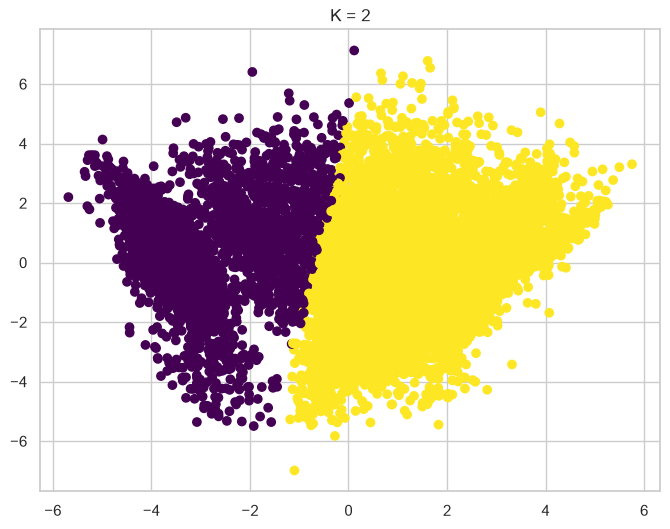

In [70]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=clusters_2,
    cmap="viridis"
)

plt.title("K = 2")

plt.show()

## Plot for k=3

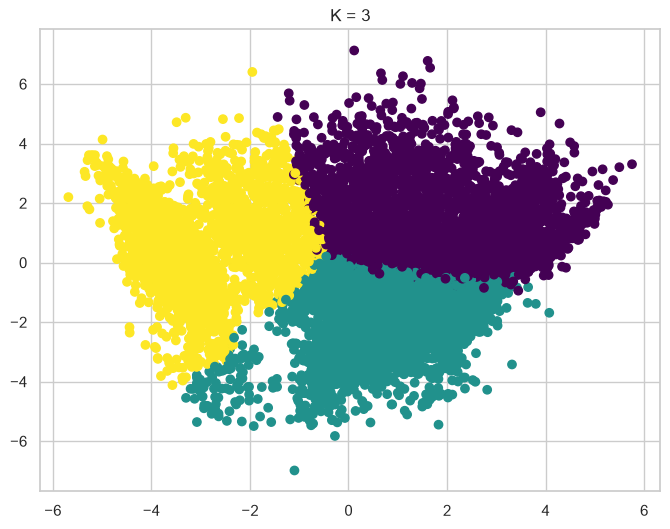

In [74]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=clusters_3,
    cmap="viridis"
)

plt.title("K = 3")

plt.show()

## Plot for k=6

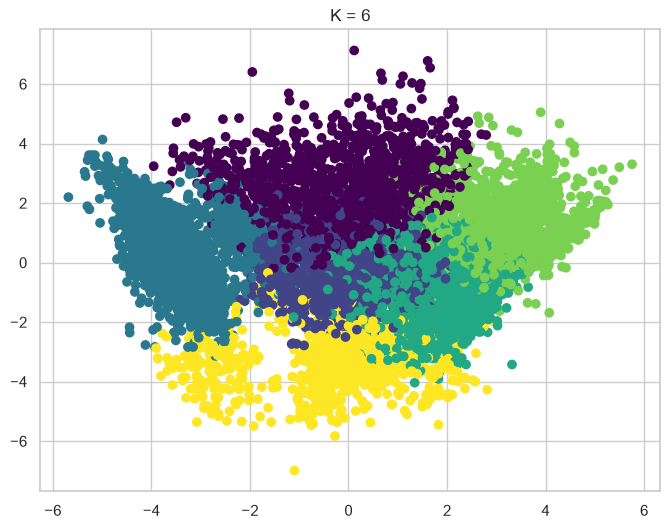

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=clusters_6,
    cmap="viridis"
)

plt.title("K = 6")

plt.show()

## Calculate all evaluation metrics

In [75]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

results = []

cluster_dict = {
    2: clusters_2,
    3: clusters_3,
    6: clusters_6
}

for k, labels in cluster_dict.items():

    results.append({
        "K": k,
        "Silhouette Score": round(silhouette_score(X_pca, labels), 4),
        "Calinski-Harabasz": round(calinski_harabasz_score(X_pca, labels), 2),
        "Davies-Bouldin": round(davies_bouldin_score(X_pca, labels), 4)
    })

import pandas as pd

metrics_df = pd.DataFrame(results)

metrics_df

,K,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,2,0.2619,3241.61,1.4583
1,3,0.2347,2821.18,1.6270
2,6,0.2292,2185.41,1.4013


## Cluster Sizes

In [76]:
print("K=2")
print(df_k2["Cluster"].value_counts())

print("\nK=3")
print(df_k3["Cluster"].value_counts())

print("\nK=6")
print(df_k6["Cluster"].value_counts())

K=2
Cluster
1    5787
0    3163
Name: count, dtype: int64

K=3
Cluster
0    3178
1    2909
2    2863
Name: count, dtype: int64

K=6
Cluster
2    2196
3    1696
4    1463
1    1372
0    1218
5    1005
Name: count, dtype: int64


## Customer profiles

In [77]:
print("========== K = 2 ==========")
display(df_k2.groupby("Cluster").mean().round(2))

print("========== K = 3 ==========")
display(df_k3.groupby("Cluster").mean().round(2))

print("========== K = 6 ==========")
display(df_k6.groupby("Cluster").mean().round(2))

========== K = 2 ==========


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2363.34,0.90,151.58,120.70,30.92,2162.68,0.10,0.06,0.04,0.29,7.15,1.73,4309.07,1785.66,1106.34,0.04,11.32
1,1127.84,0.86,1468.68,850.27,618.84,331.84,0.71,0.28,0.54,0.05,1.12,21.80,4595.74,1704.44,731.42,0.22,11.62


========== K = 3 ==========


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2060.69,0.98,2306.27,1432.05,874.58,774.13,0.84,0.46,0.61,0.10,2.57,32.80,5772.31,2644.88,1205.76,0.16,11.79
1,232.31,0.72,467.82,176.97,291.33,38.24,0.52,0.08,0.43,0.01,0.14,8.30,3300.20,705.23,217.61,0.27,11.38
2,2367.23,0.92,100.76,82.59,18.22,2161.88,0.07,0.04,0.03,0.30,7.17,1.15,4289.00,1765.53,1097.21,0.03,11.35


========== K = 6 ==========


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,3504.84,0.97,1359.32,759.87,599.72,2936.90,0.69,0.29,0.52,0.38,10.11,22.41,5983.91,3034.78,1738.78,0.04,11.46
1,1177.00,0.94,682.62,610.36,72.61,157.24,0.32,0.24,0.09,0.04,0.57,6.45,3677.95,1022.65,709.81,0.04,11.63
2,2302.73,0.93,16.45,14.36,2.15,2106.31,0.02,0.01,0.00,0.29,6.80,0.22,4156.79,1716.01,1044.33,0.03,11.40
3,416.11,0.92,695.87,46.22,650.52,39.96,0.85,0.03,0.81,0.01,0.15,15.52,2989.64,809.43,617.54,0.33,11.45
4,1584.62,0.98,3359.26,2244.43,1114.84,85.16,0.93,0.68,0.64,0.02,0.25,44.32,6905.80,3118.16,706.87,0.29,11.89
5,37.30,0.34,254.28,145.14,109.43,149.46,0.26,0.07,0.19,0.02,0.44,3.84,3570.06,705.65,99.46,0.21,11.26


## summary table

In [78]:
summary = pd.DataFrame({
    "Criteria":[
        "Elbow",
        "Silhouette Score",
        "Cluster Sizes",
        "Distinct Customer Profiles",
        "Easy to Explain"
    ],

    "K=2":[
        "Possible",
        round(silhouette_score(X_pca, clusters_2),4),
        "",
        "",
        ""
    ],

    "K=3":[
        "Possible",
        round(silhouette_score(X_pca, clusters_3),4),
        "",
        "",
        ""
    ],

    "K=6":[
        "Strong Bend",
        round(silhouette_score(X_pca, clusters_6),4),
        "",
        "",
        ""
    ]
})

summary

,Criteria,K=2,K=3,K=6
0,Elbow,Possible,Possible,Strong Bend
1,Silhouette Score,0.2619,0.2347,0.2292
2,Cluster Sizes,,,
3,Distinct Customer Profiles,,,
4,Easy to Explain,,,
